In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulation du portefeuille

In [9]:
# On part d'un capital initial
initial_cash = 100000.0
cash = initial_cash

# Dictionnaire pour suivre les positions : ticker -> (nombre de parts, prix d'achat moyen)
holdings = {}

# Listes pour enregistrer l'évolution du portefeuille et les trades réalisés
portfolio_history = []  # Liste de tuples (Datetime, portfolio_value)
trades = []             # Chaque trade sera un dictionnaire avec les infos utiles

In [11]:
# Chargement du fichier
df = pd.read_csv('cac40_clean_format.csv', parse_dates=['Datetime'])

# Filtrer pour ne garder que les lignes où la valeur de la colonne 'Price' est "Close"
df = df[df['Price'] == 'Close']

# Optionnel : supprimer la colonne 'Price' puisqu'on utilise uniquement la colonne 'Value'
df.drop(columns=['Price'], inplace=True)

# Trier par date
df.sort_values('Datetime', inplace=True)

In [12]:
np.random.seed(42)
df['Signal'] = np.random.choice([0, 1, 2], size=len(df), p=[0.2, 0.2, 0.6])

In [13]:
# Simulation : on parcourt les données par timestamp
for dt, group in df.groupby('Datetime'):
    # Pour chaque action à l'instant dt
    for idx, row in group.iterrows():
        ticker = row['Ticker']
        price = row['Value']
        signal = row['Signal']
        
        # Acheter (signal 0) : investir 10% du cash disponible si l'action n'est pas déjà détenue
        if signal == 0:
            if ticker not in holdings:
                allocation = 0.10 * cash
                shares = allocation / price
                holdings[ticker] = (shares, price)
                cash -= shares * price
                trades.append({
                    'Datetime': dt,
                    'Ticker': ticker,
                    'Action': 'Buy',
                    'Price': price,
                    'Shares': shares,
                    'Profit': np.nan
                })
                
        # Vendre (signal 1) : vendre si l'action est détenue
        elif signal == 1:
            if ticker in holdings:
                shares, buy_price = holdings[ticker]
                cash += shares * price
                profit = shares * (price - buy_price)
                trades.append({
                    'Datetime': dt,
                    'Ticker': ticker,
                    'Action': 'Sell',
                    'Price': price,
                    'Shares': shares,
                    'Profit': profit
                })
                holdings.pop(ticker)
        # Signal 2 (attendre) : aucune action

    # Calcul de la valeur totale du portefeuille à ce timestamp
    portfolio_value = cash
    for t, (shares, _) in holdings.items():
        # Récupérer le prix courant dans le groupe ou utiliser le dernier prix connu
        current_price = group[group['Ticker'] == t]['Value']
        if not current_price.empty:
            portfolio_value += shares * current_price.values[0]
    portfolio_history.append((dt, portfolio_value))
    
# Conversion de l'historique en DataFrame
portfolio_df = pd.DataFrame(portfolio_history, columns=['Datetime', 'PortfolioValue'])
portfolio_df.set_index('Datetime', inplace=True)
portfolio_df.sort_index(inplace=True)

# 2. Calcul des métriques de performance

In [14]:
# Calcul des rendements horaires
portfolio_df['Return'] = portfolio_df['PortfolioValue'].pct_change()

In [15]:
# Rendement total
total_return = (portfolio_df['PortfolioValue'].iloc[-1] / initial_cash) - 1

Pour le calcul du rendement annualisé, il faut connaître le nombre d'heures de trading par an.

Par exemple, si l'on considère environ 6.5 heures de trading par jour et 252 jours/an :

In [16]:
trading_hours_per_year = 252 * 6.5

In [17]:
# On suppose ici que la simulation couvre uniquement des heures de trading
num_hours = len(portfolio_df)
annualized_return = (portfolio_df['PortfolioValue'].iloc[-1] / initial_cash) ** (trading_hours_per_year / num_hours) - 1

In [18]:
# Volatilité (écart-type des rendements horaires)
volatility = portfolio_df['Return'].std()

In [19]:
# Maximum Drawdown
cumulative_max = portfolio_df['PortfolioValue'].cummax()
drawdown = (portfolio_df['PortfolioValue'] - cumulative_max) / cumulative_max
max_drawdown = drawdown.min()

In [20]:
# Ratio de Sharpe (on suppose un taux sans risque de 0)
sharpe_ratio = portfolio_df['Return'].mean() / portfolio_df['Return'].std() * np.sqrt(trading_hours_per_year)

In [21]:
# Ratio de Sortino : calcul de l'écart-type des rendements négatifs (downside deviation)
downside_returns = portfolio_df['Return'][portfolio_df['Return'] < 0]
downside_std = downside_returns.std()
sortino_ratio = portfolio_df['Return'].mean() / downside_std * np.sqrt(trading_hours_per_year)

In [22]:
# Affichage des résultats
print(f"Total Return: {total_return*100:.2f}%")
print(f"Annualized Return: {annualized_return*100:.2f}%")
print(f"Hourly Volatility: {volatility*100:.2f}%")
print(f"Maximum Drawdown: {max_drawdown*100:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Sortino Ratio: {sortino_ratio:.2f}")

Total Return: 8.40%
Annualized Return: 2.93%
Hourly Volatility: 0.20%
Maximum Drawdown: -11.43%
Sharpe Ratio: 0.40
Sortino Ratio: 0.51


# 3. Visualisations

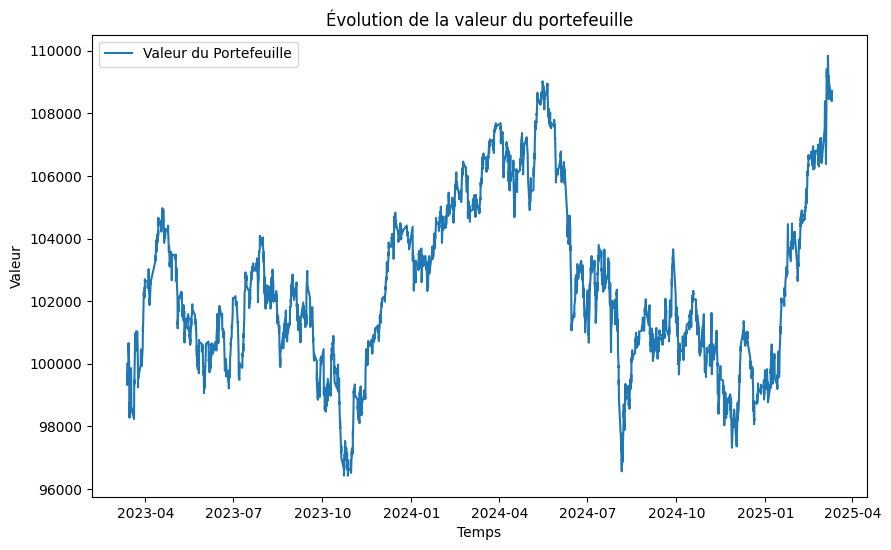

In [23]:
# Évolution de la valeur du portefeuille
plt.figure(figsize=(10, 6))
plt.plot(portfolio_df.index, portfolio_df['PortfolioValue'], label='Valeur du Portefeuille')
plt.xlabel('Temps')
plt.ylabel('Valeur')
plt.title("Évolution de la valeur du portefeuille")
plt.legend()
plt.show()

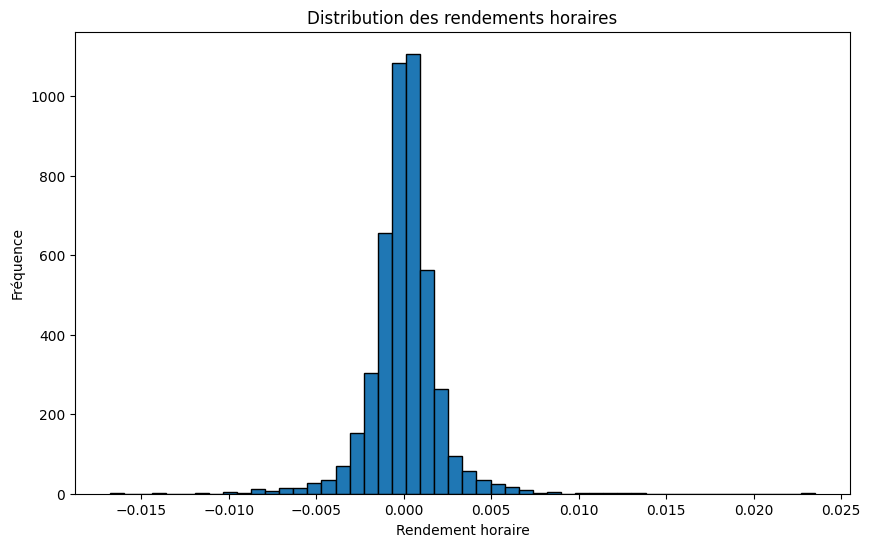

In [24]:
# Histogramme des rendements horaires
plt.figure(figsize=(10, 6))
plt.hist(portfolio_df['Return'].dropna(), bins=50, edgecolor='black')
plt.xlabel('Rendement horaire')
plt.ylabel('Fréquence')
plt.title("Distribution des rendements horaires")
plt.show()

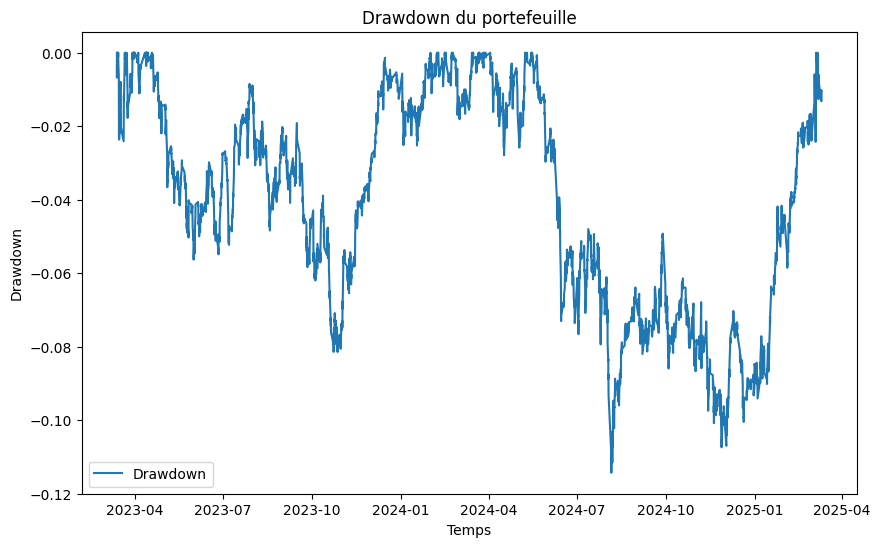

In [25]:
# Affichage du drawdown
plt.figure(figsize=(10, 6))
plt.plot(portfolio_df.index, drawdown, label='Drawdown')
plt.xlabel('Temps')
plt.ylabel('Drawdown')
plt.title("Drawdown du portefeuille")
plt.legend()
plt.show()

# 4. Analyse des trades réalisés

In [26]:
# Création d'un DataFrame des trades
trades_df = pd.DataFrame(trades)
trades_df['Datetime'] = pd.to_datetime(trades_df['Datetime'])
trades_df.sort_values('Datetime', inplace=True)

# On ne s'intéresse qu'aux trades de vente pour calculer le profit par transaction
sell_trades = trades_df[(trades_df['Action'] == 'Sell') & (trades_df['Profit'].notna())]

if not sell_trades.empty:
    # Taux de réussite : pourcentage de trades avec profit positif
    success_rate = (sell_trades['Profit'] > 0).mean()
    # Ratio Gain/Perte : moyenne des gains positifs / moyenne des pertes (en valeur absolue)
    avg_gain = sell_trades[sell_trades['Profit'] > 0]['Profit'].mean()
    avg_loss = abs(sell_trades[sell_trades['Profit'] < 0]['Profit'].mean())
    gain_loss_ratio = avg_gain / avg_loss if avg_loss != 0 else np.nan
else:
    success_rate = np.nan
    gain_loss_ratio = np.nan

In [27]:
print(f"Taux de réussite des trades: {success_rate*100:.2f}%")
print(f"Ratio Gain/Perte: {gain_loss_ratio:.2f}")
print(f"Nombre total de trades: {len(trades_df)}")

Taux de réussite des trades: 50.91%
Ratio Gain/Perte: 0.96
Nombre total de trades: 36433


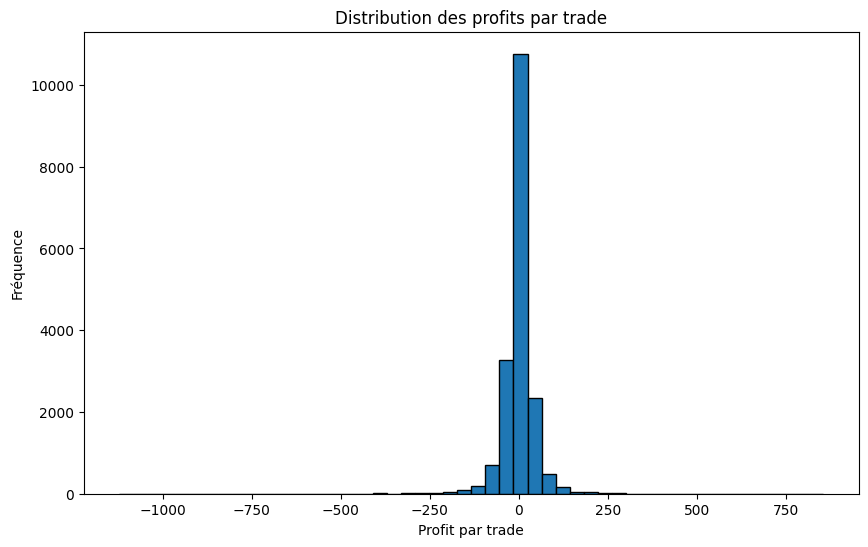

In [28]:
# Histogramme de la distribution des profits par trade
if not sell_trades.empty:
    plt.figure(figsize=(10, 6))
    plt.hist(sell_trades['Profit'], bins=50, edgecolor='black')
    plt.xlabel('Profit par trade')
    plt.ylabel('Fréquence')
    plt.title("Distribution des profits par trade")
    plt.show()